In [1]:
import os
import json
import cv2
import numpy as np

DATA_PATH = "Data/Hurricane"

X = []
y = [] 


for json_file in os.listdir(f"{DATA_PATH}/JSON"):
    
    with open(f"{DATA_PATH}/JSON/{json_file}") as f:
        data = json.load(f)

    # Load original image
    frame_path = os.path.join(DATA_PATH, data["Frame_Name"])
    image = cv2.imread(frame_path)
    image = cv2.resize(image, (224, 224))
    image = image / 255.0

    # Loop through buildings
    for building in data["Buildings"]:
        
        mask_filename = building[2]
        label = building[3]  # damage level

        mask_path = os.path.join(DATA_PATH, "MASK", mask_filename)

        if not os.path.exists(mask_path):
            continue

        # Load mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (224, 224))
        mask = mask / 255.0
        mask = np.expand_dims(mask, axis=-1)

        # Combine image + mask
        combined = np.concatenate([image, mask], axis=-1)

        X.append(combined)
        y.append(label)

X = np.array(X)
y = np.array(y)

In [2]:
X = X.reshape(X.shape[0], -1)  # Flatten the combined image and mask

In [3]:
X.shape

(1458, 200704)

In [6]:
import matplotlib.pyplot as plt
from collections import Counter

print(f"Feature matrix shape: {X.shape}")
print(f"Label array shape:    {y.shape}")
print(f"Number of samples:    {X.shape[0]}")
print(f"Number of features:   {X.shape[1]}")
print(f"Unique labels:        {sorted(set(y))}")
print(f"Label counts:         {dict(sorted(Counter(y).items()))}")

Feature matrix shape: (1458, 200704)
Label array shape:    (1458,)
Number of samples:    1458
Number of features:   200704
Unique labels:        [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Label counts:         {np.int64(0): 168, np.int64(1): 264, np.int64(2): 196, np.int64(3): 464, np.int64(4): 258, np.int64(5): 108}


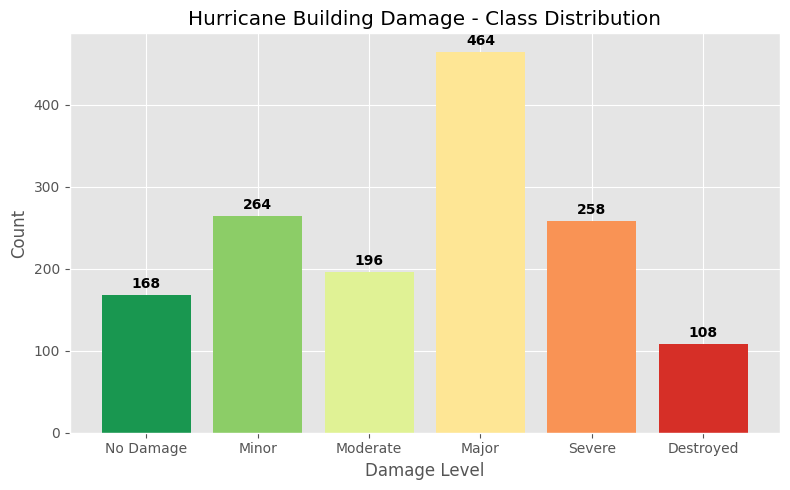

In [7]:
plt.style.use('ggplot')

damage_labels = {
    0: 'No Damage',
    1: 'Minor',
    2: 'Moderate',
    3: 'Major',
    4: 'Severe',
    5: 'Destroyed'
}

counts = Counter(y)
levels = sorted(counts.keys())
values = [counts[l] for l in levels]
labels = [damage_labels.get(l, str(l)) for l in levels]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(levels))))
ax.set_xlabel('Damage Level')
ax.set_ylabel('Count')
ax.set_title('Hurricane Building Damage - Class Distribution')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()
print(f"NaN values in X: {nan_count}")
print(f"Inf values in X: {inf_count}")

if nan_count > 0:
    print("Replacing NaN values with 0...")
    X = np.nan_to_num(X, nan=0.0)

if inf_count > 0:
    print("Replacing Inf values with 0...")
    X = np.nan_to_num(X, posinf=0.0, neginf=0.0)

print("Data quality check passed.")

NaN values in X: 0
Inf values in X: 0
Data quality check passed.


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Training set: 1166 samples
Testing set:  292 samples


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print(f"Scaled feature matrix shape: {X_test_scaled.shape}")
print(f"Scaled feature matrix shape: {X_train_scaled.shape}")

print(f"Mean (first 5 features):  {X_test_scaled.mean(axis=0)[:5]}")
print(f"Mean (first 5 features):  {X_train_scaled.mean(axis=0)[:5]}")

print(f"Std  (first 5 features):  {X_test_scaled.std(axis=0)[:5]}")
print(f"Std  (first 5 features):  {X_train_scaled.std(axis=0)[:5]}")

Scaled feature matrix shape: (292, 200704)
Scaled feature matrix shape: (1166, 200704)
Mean (first 5 features):  [1.09387385e-15 3.42800370e-15 5.56898515e-15 0.00000000e+00
 6.62635852e-15]
Mean (first 5 features):  [-1.48145742e-14  1.60472931e-14 -2.50704736e-16  0.00000000e+00
 -2.84004762e-14]
Std  (first 5 features):  [1. 1. 1. 0. 1.]
Std  (first 5 features):  [1. 1. 1. 0. 1.]


In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


print("X_train_pca shape:", X_train_pca.shape)
print("X_test_pca shape:", X_test_pca.shape)

print(f"X_test_scaled Original features:  {X_test_scaled.shape[1]}")
print(f"X_train_scaled Original features:  {X_train_scaled.shape[1]}")

print(f"X_test_PCA components:     {X_test_pca.shape[1]}")
print(f"X_train_PCA components:     {X_train_pca.shape[1]}")

print(f"Variance retained:  {pca.explained_variance_ratio_.sum():.4f}")

X_train_pca shape: (1166, 275)
X_test_pca shape: (292, 275)
X_test_scaled Original features:  200704
X_train_scaled Original features:  200704
X_test_PCA components:     275
X_train_PCA components:     275
Variance retained:  0.9500


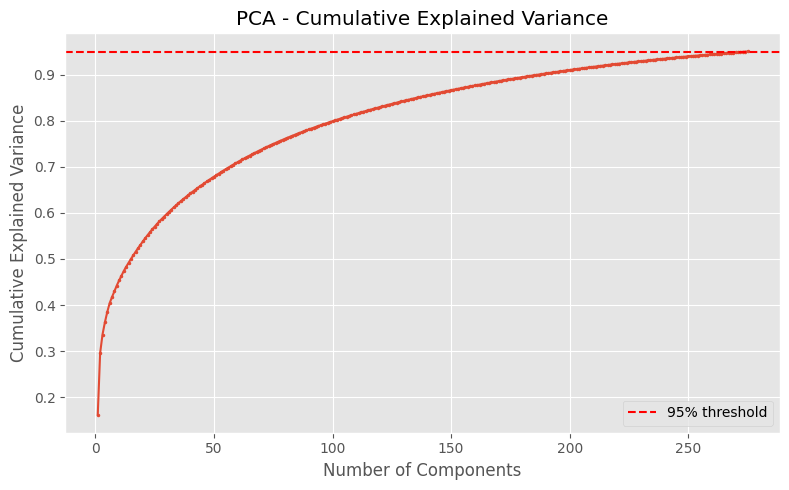

In [14]:
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='.', markersize=3)
ax.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA - Cumulative Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

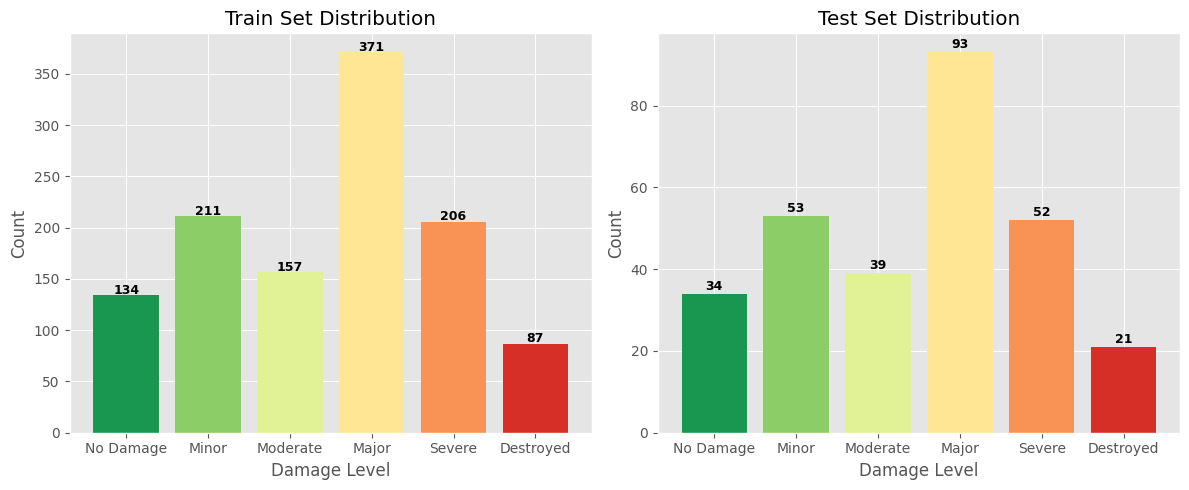

In [15]:
train_counts = Counter(y_train)
test_counts = Counter(y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, counts, title in zip(axes, [train_counts, test_counts], ['Train Set', 'Test Set']):
    levels = sorted(counts.keys())
    vals = [counts[l] for l in levels]
    lbls = [damage_labels.get(l, str(l)) for l in levels]
    ax.bar(lbls, vals, color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(levels))))
    ax.set_title(f'{title} Distribution')
    ax.set_xlabel('Damage Level')
    ax.set_ylabel('Count')
    for i, (x, v) in enumerate(zip(range(len(levels)), vals)):
        ax.text(x, v + 1, str(v), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression( max_iter=5000, class_weight="balanced", solver="lbfgs"),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [17]:
from sklearn.metrics import accuracy_score, classification_report

results = []

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc
    })

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

/Users/luisromero/Desktop/Spring 2026/AI/FinalProject/AI-Final-Project-GroupRRM/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
Accuracy: 0.3013698630136986
              precision    recall  f1-score   support

           0       0.24      0.35      0.29        34
           1       0.46      0.32      0.38        53
           2       0.17      0.31      0.22        39
           3       0.42      0.37      0.39        93
           4       0.47      0.17      0.25        52
           5       0.12      0.19      0.15        21

    accuracy                           0.30       292
   macro avg       0.31      0.29      0.28       292
weighted avg       0.36      0.30      0.31       292


Random Forest
Accuracy: 0.4383561643835616
              precision    recall  f1-score   support

           0       0.40      0.18      0.24        34
           1       0.54      0.38      0.44        53
           2       0.64      0.18      0.28        39
           3       0.41      0.84      0.55        93
           4       0.50      0.31      0.38        52
           5       0.20      0.05     